In [1]:
!nvidia-smi

Mon Aug 31 14:58:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   30C    P0             43W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
!pip -q install -U transformers datasets accelerate evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 151.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 160.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 129.9 MB/s eta 0:00:00


In [34]:
#Libraries
import os
import random
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from transformers import set_seed
from transformers import AutoTokenizer
from transformers import TrainingArguments
from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [5]:
#Setup reproducibility
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

set_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Seed:", SEED)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))

Seed: 42
PyTorch: 2.11.0+cu128
CUDA: 12.8
GPU: NVIDIA A100-SXM4-40GB


In [7]:
#Load datasets
train_df = pd.read_csv("/content/phishing_train.csv")
val_df   = pd.read_csv("/content/phishing_validation.csv")
test_df  = pd.read_csv("/content/phishing_test.csv")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain labels:")
print(train_df["label"].value_counts())

print("\nValidation labels:")
print(val_df["label"].value_counts())

print("\nTest labels:")
print(test_df["label"].value_counts())

Train: (14015, 4)
Validation: (1752, 4)
Test: (1752, 4)

Train labels:
label
0    8782
1    5233
Name: count, dtype: int64

Validation labels:
label
0    1098
1     654
Name: count, dtype: int64

Test labels:
label
0    1098
1     654
Name: count, dtype: int64


In [9]:
#Convert dataset to hugging face
train_dataset = Dataset.from_pandas(
    train_df[["processed_text", "label"]],
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df[["processed_text", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["processed_text", "label"]],
    preserve_index=False
)

print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['processed_text', 'label'],
    num_rows: 14015
})
Dataset({
    features: ['processed_text', 'label'],
    num_rows: 1752
})
Dataset({
    features: ['processed_text', 'label'],
    num_rows: 1752
})


In [11]:
#Load RoBERTa-large tokenizer
MODEL_NAME = "FacebookAI/roberta-large"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded:", MODEL_NAME)

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Tokenizer loaded: FacebookAI/roberta-large


In [12]:
#Tokenize the data
MAX_LENGTH = 512

def tokenize_function(examples):
    return tokenizer(
        examples["processed_text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False
    )

train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["processed_text"]
)

val_tokenized = val_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["processed_text"]
)

test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["processed_text"]
)

print(train_tokenized)

Map:   0%|          | 0/14015 [00:00<?, ? examples/s]

Map:   0%|          | 0/1752 [00:00<?, ? examples/s]

Map:   0%|          | 0/1752 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 14015
})


In [14]:
#Load classification model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

print("RoBERTa-large loaded.")

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.42GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa-large loaded.


In [19]:
#Define evaluation metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        pos_label=1,
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }
print ("Metrics defined")

Metrics defined


In [29]:
  #Create trainer
  training_args = TrainingArguments(
    output_dir="/content/roberta_large_results",

    num_train_epochs=3,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,

    gradient_accumulation_steps=2,

    learning_rate=2e-5,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_strategy="steps",
    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    bf16=True,

    seed=42,
    data_seed=42,

    report_to="none",

    save_total_limit=2
)

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,

    processing_class=tokenizer,

    compute_metrics=compute_metrics
)

print("Trainer ready.")

Trainer ready.


In [30]:
#Train the model
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.193123,0.041523,0.991438,0.993818,0.983180,0.988470
2,0.055827,0.058059,0.990297,0.984779,0.989297,0.987033
3,0.027509,0.063161,0.991438,0.990783,0.986239,0.988506


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [31]:
#evaluate on test set
test_results = trainer.evaluate(
    test_tokenized,
    metric_key_prefix="test"
)

print(test_results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.027509,0.049934,3,0.992580,0.992320,0.987768,0.990038


{'test_loss': 0.049934010952711105, 'test_accuracy': 0.992579908675799, 'test_precision': 0.9923195084485407, 'test_recall': 0.9877675840978594, 'test_f1': 0.9900383141762452}


                precision    recall  f1-score   support

    Safe Email     0.9927    0.9954    0.9941      1098
Phishing Email     0.9923    0.9878    0.9900       654

      accuracy                         0.9926      1752
     macro avg     0.9925    0.9916    0.9921      1752
  weighted avg     0.9926    0.9926    0.9926      1752

Confusion Matrix:
[[1093    5]
 [   8  646]]


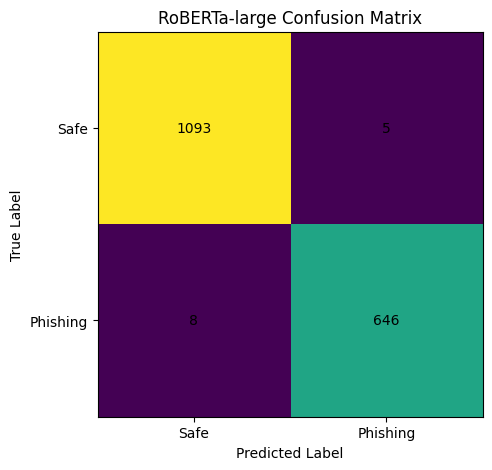

In [35]:
#Create a classification report and confusion matrix
predictions = trainer.predict(test_tokenized)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

print(classification_report(
    y_true,
    y_pred,
    target_names=["Safe Email", "Phishing Email"],
    digits=4
))

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("RoBERTa-large Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["Safe", "Phishing"])
plt.yticks([0, 1], ["Safe", "Phishing"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()